# FRED Macro Dashboard and Regime Diagnostics

Pulls a compact macro pack from FRED, builds a clean long table, enriches it with mixed-frequency as-of changes, then runs regime, lead-lag, persistence, curve, and score diagnostics with a final score visualization and one Excel export.

In [14]:
import warnings
warnings.filterwarnings("ignore")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns

pd.options.mode.chained_assignment = None
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")

## Data pull from FRED

Reads the API key from `fred_api_key.txt`, pulls each series, and stacks results into one long table.

In [16]:
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

def get_fred_key(filepath="fred_api_key.txt") -> str:
    # Reads a local key file formatted like: FRED_API_KEY="..."
    content = Path(filepath).read_text().strip()
    return content.split("=")[-1].replace('"', "").replace("'", "").strip()

def fetch_fred_series(series_id: str, api_key: str, sleep_seconds: float = 0.1) -> pd.DataFrame:
    # Requests observations from FRED and returns a minimal date/value dataframe
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "sort_order": "asc",
    }
    response = requests.get(BASE_URL, params=params, timeout=30)
    response.raise_for_status()
    observations = response.json().get("observations", [])
    df = pd.DataFrame(observations)[["date", "value"]] if observations else pd.DataFrame(columns=["date", "value"])
    time.sleep(sleep_seconds)
    return df

FRED_API_KEY = get_fred_key()

MACRO_SERIES = {
    "real_gdp": {"id": "GDPC1", "cat": "Growth", "u": "Bil. chained 2017$"},
    "cpi": {"id": "CPIAUCSL", "cat": "Inflation", "u": "Index"},
    "unemployment_rate": {"id": "UNRATE", "cat": "Labor", "u": "%"},
    "fed_funds_rate": {"id": "FEDFUNDS", "cat": "Rates", "u": "%"},
    "ust_10y_yield": {"id": "DGS10", "cat": "Rates", "u": "%"},
    "ust_2y_yield": {"id": "DGS2", "cat": "Rates", "u": "%"},
    "curve_10y_2y": {"id": "T10Y2Y", "cat": "Rates", "u": "Pct. points"},
    "vix": {"id": "VIXCLS", "cat": "Risk", "u": "Index"},
    "recession": {"id": "USREC", "cat": "Regime", "u": "Flag"},
}

series_frames = []
for metric_name, info in MACRO_SERIES.items():
    series_df = fetch_fred_series(info["id"], FRED_API_KEY)
    series_df["metric"] = metric_name
    series_df["category"] = info["cat"]
    series_df["unit"] = info["u"]
    series_df["value"] = pd.to_numeric(series_df["value"], errors="coerce")
    series_frames.append(series_df)

final_macro_df = pd.concat(series_frames, ignore_index=True)[["date", "metric", "category", "unit", "value"]]

final_macro_df

,date,metric,category,unit,value
0,1947-01-01,real_gdp,Growth,Bil. chained 2017$,2182.681
1,1947-04-01,real_gdp,Growth,Bil. chained 2017$,2176.892
2,1947-07-01,real_gdp,Growth,Bil. chained 2017$,2172.432
3,1947-10-01,real_gdp,Growth,Bil. chained 2017$,2206.452
4,1948-01-01,real_gdp,Growth,Bil. chained 2017$,2239.682
...,...,...,...,...,...
57239,2025-09-01,recession,Regime,Flag,0.000
57240,2025-10-01,recession,Regime,Flag,0.000
57241,2025-11-01,recession,Regime,Flag,0.000
57242,2025-12-01,recession,Regime,Flag,0.000


## Cleaning and enrichment

Cleans dates, deduplicates metric-date rows, infers frequency, adds calendar fields, mixed-frequency as-of changes, percentiles, z-scores, and creates wide panels used by later plots.

In [18]:
def add_calendar_fields(df: pd.DataFrame) -> pd.DataFrame:
    # Adds convenient time buckets used throughout the notebook
    out = df.copy()
    out["year"] = out["date"].dt.year
    out["quarter_num"] = out["date"].dt.quarter
    out["quarter"] = out["date"].dt.to_period("Q").astype(str)
    out["month"] = out["date"].dt.to_period("M").astype(str)
    out["month_start"] = out["date"].dt.to_period("M").dt.start_time
    out["quarter_start"] = out["date"].dt.to_period("Q").dt.start_time
    out["week_start"] = (out["date"] - pd.to_timedelta(out["date"].dt.weekday, unit="D")).dt.normalize()
    return out

def build_metric_meta(df: pd.DataFrame) -> pd.DataFrame:
    # Summarizes per-metric coverage and infers rough frequency via median observation gap
    x = df.copy()
    x["obs_gap_days"] = x.groupby("metric")["date"].diff().dt.days

    meta = (
        x.groupby(["metric", "category", "unit"], as_index=False)
        .agg(
            start_date=("date", "min"),
            end_date=("date", "max"),
            obs_count=("date", "count"),
            median_gap_days=("obs_gap_days", "median"),
            min_value=("value", "min"),
            max_value=("value", "max"),
        )
    )

    meta["frequency_hint"] = "irregular"
    meta.loc[meta["median_gap_days"] <= 2, "frequency_hint"] = "daily-ish"
    meta.loc[(meta["median_gap_days"] > 2) & (meta["median_gap_days"] <= 10), "frequency_hint"] = "weekly-ish"
    meta.loc[(meta["median_gap_days"] > 10) & (meta["median_gap_days"] <= 45), "frequency_hint"] = "monthly-ish"
    meta.loc[(meta["median_gap_days"] > 45) & (meta["median_gap_days"] <= 120), "frequency_hint"] = "quarterly-ish"
    meta.loc[meta["median_gap_days"] > 120, "frequency_hint"] = "annual/irregular"
    return meta

def add_base100(df: pd.DataFrame) -> pd.DataFrame:
    # Normalizes each metric to its first valid observation for cross-series comparison
    out = df.copy()
    out["value_base100"] = np.nan
    for metric_name, g in out.groupby("metric", sort=False):
        valid = g["value"].dropna()
        if valid.empty:
            continue
        base_val = valid.iloc[0]
        if pd.notna(base_val) and base_val != 0:
            out.loc[g.index, "value_base100"] = (g["value"] / base_val) * 100
    return out

def add_asof_stats(df: pd.DataFrame, horizons: dict) -> pd.DataFrame:
    # Mixed-frequency as-of matching: for each date, finds the last observation at or before (date - offset)
    enriched = []
    for metric_name, g in df.groupby("metric", sort=False):
        g = g.sort_values("date").copy()
        g["row_id"] = np.arange(len(g))

        ref = g[["date", "value"]].rename(columns={"date": "ref_date", "value": "old_val"}).sort_values("ref_date")

        for label, offset in horizons.items():
            lookup = g[["row_id", "date"]].copy()
            lookup["lookup_date"] = lookup["date"] - offset

            matched = pd.merge_asof(
                lookup.sort_values("lookup_date"),
                ref,
                left_on="lookup_date",
                right_on="ref_date",
                direction="backward",
            ).sort_values("row_id")

            g[f"value_{label}_ago"] = matched["old_val"].to_numpy()
            g[f"ref_date_{label}"] = matched["ref_date"].to_numpy()
            g[f"chg_{label}"] = g["value"] - g[f"value_{label}_ago"]
            g[f"pct_{label}"] = (g[f"chg_{label}"] / g[f"value_{label}_ago"].replace(0, np.nan)) * 100

        g = g.drop(columns=["row_id"])
        enriched.append(g)

    return pd.concat(enriched, ignore_index=True).sort_values(["metric", "date"]).reset_index(drop=True)

def add_zscore_percentile(df: pd.DataFrame) -> pd.DataFrame:
    # Adds within-metric z-score and percentile rank
    out_groups = []
    for metric_name, g in df.groupby("metric", sort=False):
        g = g.copy()
        mu = g["value"].mean()
        sigma = g["value"].std()
        g["z_score"] = (g["value"] - mu) / sigma if pd.notna(sigma) and sigma != 0 else np.nan
        g["percentile"] = g["value"].rank(pct=True) * 100
        out_groups.append(g)
    return pd.concat(out_groups, ignore_index=True).sort_values(["metric", "date"]).reset_index(drop=True)

def compute_recession_spans(macro_long: pd.DataFrame) -> list:
    # Converts daily/weekly recession flags into contiguous spans for shading
    spans = []
    if "recession" not in macro_long["metric"].unique():
        return spans

    rec = macro_long.loc[macro_long["metric"] == "recession", ["date", "value"]].dropna().copy()
    rec_dates = rec.loc[rec["value"] == 1, "date"].sort_values()
    if rec_dates.empty:
        return spans

    breaks = rec_dates.diff().gt(pd.Timedelta(days=32)).cumsum()
    for group_id, span in rec_dates.groupby(breaks):
        spans.append((span.min(), span.max()))
    return spans

# Clean and standardize
macro = final_macro_df.copy()
macro.columns = [c.strip().lower() for c in macro.columns]
macro["date"] = pd.to_datetime(macro["date"], errors="coerce")
macro["value"] = pd.to_numeric(macro["value"], errors="coerce")
macro = macro.dropna(subset=["date"]).sort_values(["metric", "date"]).reset_index(drop=True)

# Deduplicate metric-date observations
macro = (
    macro.groupby(["metric", "date"], as_index=False)
    .last()
    .sort_values(["metric", "date"])
    .reset_index(drop=True)
)

# Calendar fields and metadata
macro = add_calendar_fields(macro)
metric_meta = build_metric_meta(macro)
macro = macro.merge(metric_meta[["metric", "median_gap_days", "frequency_hint"]], on="metric", how="left")

# Previous observation changes
macro["value_prev_obs"] = macro.groupby("metric")["value"].shift(1)
macro["chg_prev_obs"] = macro["value"] - macro["value_prev_obs"]
macro["pct_chg_prev_obs"] = (macro["chg_prev_obs"] / macro["value_prev_obs"].replace(0, np.nan)) * 100

# Extra diffs kept for compatibility
macro["chg_1obs"] = macro.groupby("metric")["value"].diff(1)
macro["chg_5obs"] = macro.groupby("metric")["value"].diff(5)
macro["chg_21obs"] = macro.groupby("metric")["value"].diff(21)
macro["pct_252obs"] = macro.groupby("metric")["value"].pct_change(252) * 100

# Base-100 normalization
macro = add_base100(macro)

# Mixed-frequency as-of changes
HORIZONS = {
    "1d": pd.Timedelta(days=1),
    "1w": pd.Timedelta(days=7),
    "1m": pd.DateOffset(months=1),
    "1q": pd.DateOffset(months=3),
    "1y": pd.DateOffset(years=1),
}
macro_enriched = add_asof_stats(macro, HORIZONS)
macro_final = add_zscore_percentile(macro_enriched)

# Latest snapshot per metric
macro_latest_snapshot = (
    macro_final.sort_values(["metric", "date"])
    .groupby("metric", as_index=False)
    .last()
)

# Panels used for correlations and quick views
level_panel = macro_final.pivot_table(index="date", columns="metric", values="value", aggfunc="last").sort_index()
norm_panel = macro_final.pivot_table(index="date", columns="metric", values="value_base100", aggfunc="last").sort_index()
change_panel = macro_final.pivot_table(index="date", columns="metric", values="pct_chg_prev_obs", aggfunc="last").sort_index()

# Recession shading spans
recessions = compute_recession_spans(macro_final)

macro_latest_snapshot[[
    "metric", "category", "unit", "date", "value", "frequency_hint",
    "pct_chg_prev_obs", "pct_1w", "pct_1m", "pct_1q", "pct_1y", "z_score", "percentile"
]].sort_values("metric")

,metric,category,unit,date,value,frequency_hint,pct_chg_prev_obs,pct_1w,pct_1m,pct_1q,pct_1y,z_score,percentile
0,cpi,Inflation,Index,2026-01-01,326.588,monthly-ish,0.170843,0.170843,0.170843,0.550818,2.391201,2.265149,100.000000
1,curve_10y_2y,Rates,Pct. points,2026-02-27,0.590,daily-ish,-1.666667,-1.666667,-16.901408,9.090909,168.181818,-0.283053,43.701231
2,fed_funds_rate,Rates,%,2026-01-01,3.640,monthly-ish,-2.150538,-2.150538,-2.150538,-11.002445,-15.935335,-0.271866,42.724098
3,real_gdp,Growth,Bil. chained 2017$,2025-10-01,24111.830,quarterly-ish,0.353754,0.353754,0.353754,0.353754,2.227067,2.165734,100.000000
4,recession,Regime,Flag,2026-01-01,0.000,monthly-ish,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-0.626379,35.929893
5,unemployment_rate,Labor,%,2026-01-01,4.300,monthly-ish,-2.272727,-2.272727,-2.272727,0.000000,7.500000,-0.800286,24.358974
6,ust_10y_yield,Rates,%,2026-02-26,4.020,daily-ish,-0.740741,-1.470588,-4.739336,0.500000,-5.411765,-0.611270,28.217451
7,ust_2y_yield,Rates,%,2026-02-26,3.420,daily-ish,-0.869565,-1.440922,-3.932584,-0.869565,-15.555556,-0.420162,36.484312
8,vix,Risk,Index,2026-02-27,19.860,daily-ish,6.602254,4.033525,21.467890,15.398024,-6.010412,0.053943,62.098982


## Dashboard visuals

A compact overview: rates with recession shading, CPI YoY, VIX distribution by year, daily-change correlations, and current percentiles.

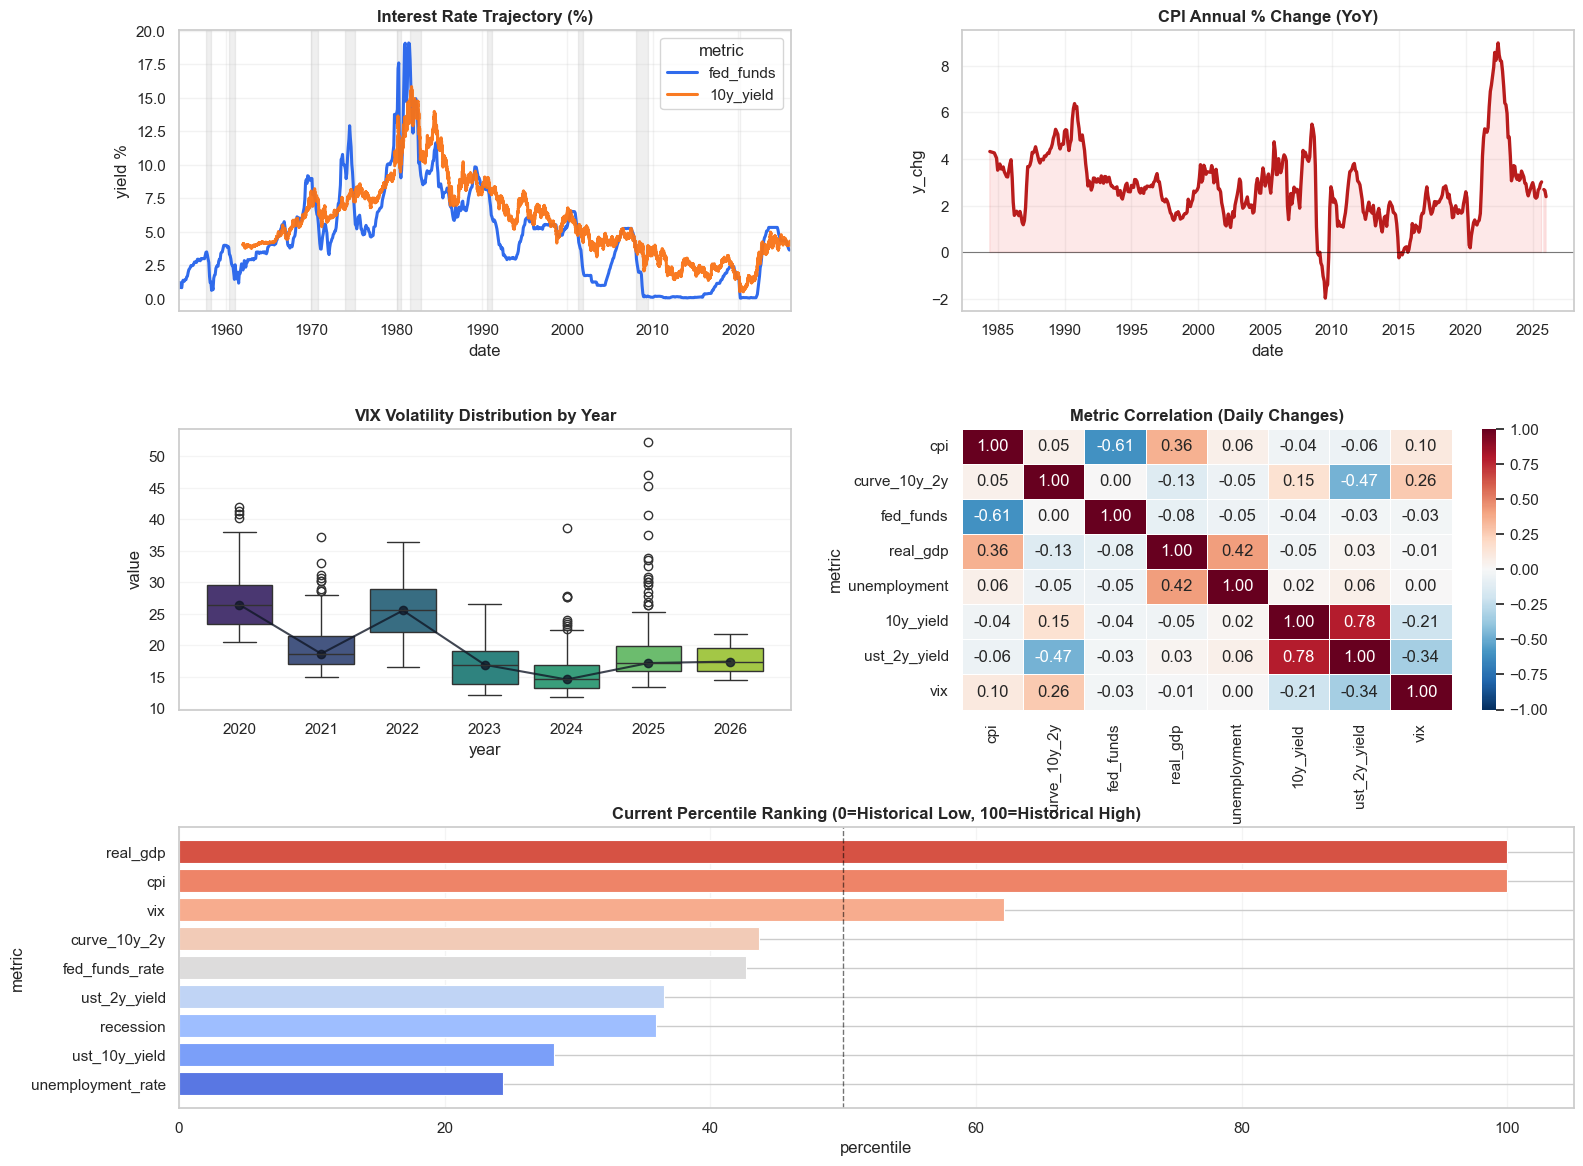

In [21]:
def apply_recession_shading(ax, start_date, end_date):
    # Shades recession spans on any axis using global recession span list
    for start, end in recessions:
        if end >= start_date and start <= end_date:
            ax.axvspan(max(start, start_date), min(end, end_date), color="gray", alpha=0.12, zorder=0)
    ax.set_xlim(start_date, end_date)

fig = plt.figure(figsize=(18, 14))
grid = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.28)

# Rates: Fed funds vs 10Y
ax1 = fig.add_subplot(grid[0, 0])
rates_plot = macro_final[macro_final["metric"].isin(["fed_funds_rate", "ust_10y_yield"])].copy()

color_map = {"fed_funds_rate": "#2563eb", "ust_10y_yield": "#f97316"}
label_map = {"fed_funds_rate": "fed_funds", "ust_10y_yield": "10y_yield"}

for metric_name, g in rates_plot.groupby("metric", sort=True):
    g = g.sort_values("date")
    ax1.plot(g["date"], g["value"], linewidth=2.2, alpha=0.95, color=color_map.get(metric_name), label=label_map.get(metric_name, metric_name))

if not rates_plot.empty:
    apply_recession_shading(ax1, rates_plot["date"].min(), rates_plot["date"].max())

ax1.set_title("Interest Rate Trajectory (%)", fontweight="bold")
ax1.set_xlabel("date")
ax1.set_ylabel("yield %")
ax1.legend(title="metric", frameon=True)
ax1.grid(True, alpha=0.25)

# CPI YoY
ax2 = fig.add_subplot(grid[0, 1])
if "cpi" in macro_final["metric"].unique():
    cpi_data = macro_final[macro_final["metric"] == "cpi"].sort_values("date").tail(500).copy()
    ax2.plot(cpi_data["date"], cpi_data["pct_1y"], color="#b91c1c", linewidth=2.4)
    ax2.fill_between(cpi_data["date"].to_numpy(), np.nan_to_num(cpi_data["pct_1y"].to_numpy(), nan=np.nan), alpha=0.12, color="#ef4444")
    ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax2.set_title("CPI Annual % Change (YoY)", fontweight="bold")
    ax2.set_xlabel("date")
    ax2.set_ylabel("y_chg")
    ax2.grid(True, alpha=0.25)
else:
    ax2.text(0.5, 0.5, "CPI not available", ha="center", va="center")
    ax2.set_axis_off()

# VIX distribution by year
ax3 = fig.add_subplot(grid[1, 0])
if "vix" in macro_final["metric"].unique():
    vix_data = macro_final[macro_final["metric"] == "vix"].dropna(subset=["value", "year"]).sort_values("date").tail(1500).copy()
    sns.boxplot(data=vix_data, x="year", y="value", ax=ax3, palette="viridis", linewidth=1)
    medians = vix_data.groupby("year")["value"].median().reset_index()
    ax3.plot(range(len(medians)), medians["value"], color="#111827", marker="o", linewidth=1.5, alpha=0.8)
    ax3.set_title("VIX Volatility Distribution by Year", fontweight="bold")
    ax3.set_xlabel("year")
    ax3.set_ylabel("value")
    ax3.grid(True, axis="y", alpha=0.2)
else:
    ax3.text(0.5, 0.5, "VIX not available", ha="center", va="center")
    ax3.set_axis_off()

# Correlation heatmap: daily percent changes
ax4 = fig.add_subplot(grid[1, 1])
pivot_levels_daily = macro_final.pivot_table(index="date", columns="metric", values="value", aggfunc="last").sort_index()
pivot_levels_daily = pivot_levels_daily.rename(columns={"ust_10y_yield": "10y_yield", "fed_funds_rate": "fed_funds", "unemployment_rate": "unemployment"})
pivot_changes_daily = pivot_levels_daily.pct_change()

corr_input = pivot_changes_daily.tail(252).copy()
corr_input = corr_input.loc[:, corr_input.count() >= 20]
corr_mat = corr_input.corr()

if not corr_mat.empty:
    sns.heatmap(
        corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        vmin=-1, vmax=1, linewidths=0.5, linecolor="white", cbar=True, ax=ax4
    )
    ax4.set_title("Metric Correlation (Daily Changes)", fontweight="bold")
    ax4.set_xlabel("")
    ax4.set_ylabel("metric")
else:
    ax4.text(0.5, 0.5, "Not enough overlapping daily change data", ha="center", va="center")
    ax4.set_axis_off()

# Percentile ranking
ax5 = fig.add_subplot(grid[2, :])
p_data = macro_latest_snapshot.sort_values("percentile").copy()
bar_colors = sns.color_palette("coolwarm", len(p_data))

ax5.barh(p_data["metric"], p_data["percentile"], color=bar_colors, edgecolor="white", linewidth=0.8)
ax5.axvline(50, color="black", linestyle="--", alpha=0.55, linewidth=1)
ax5.set_title("Current Percentile Ranking (0=Historical Low, 100=Historical High)", fontweight="bold")
ax5.set_xlabel("percentile")
ax5.set_ylabel("metric")
ax5.grid(True, axis="x", alpha=0.2)

plt.show()

# Gross Domestic Product 

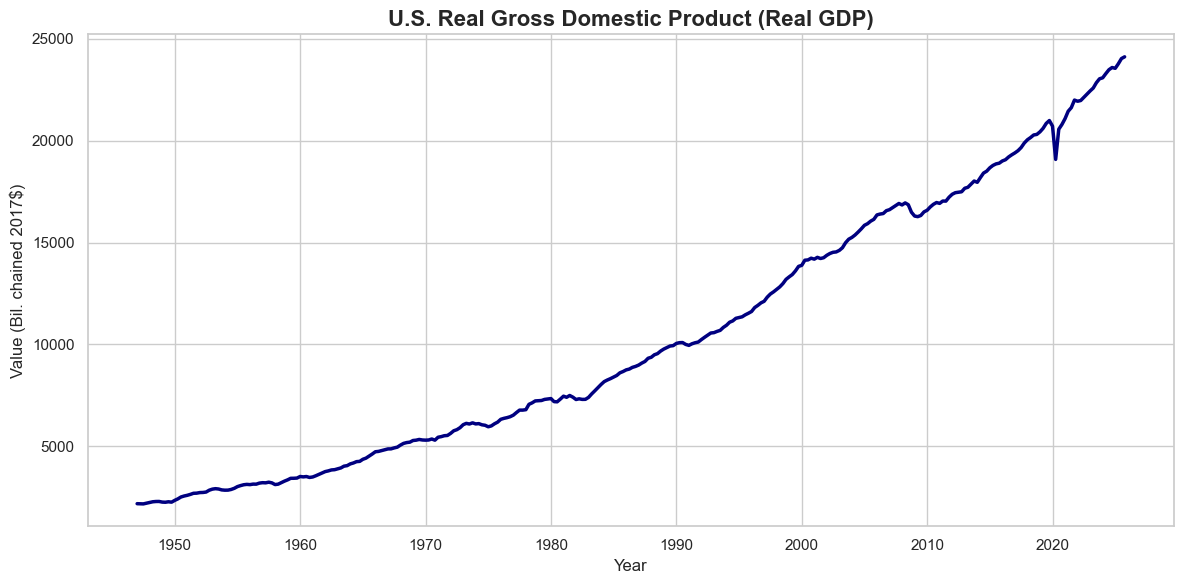

In [30]:
# Filter the combined dataframe for GDP and prepare for plotting
gdp_plot_df = final_macro_df[final_macro_df["metric"] == "real_gdp"].copy()
gdp_plot_df["date"] = pd.to_datetime(gdp_plot_df["date"])

# plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create the line plot
sns.lineplot(
    data=gdp_plot_df, 
    x="date", 
    y="value", 
    color="navy", 
    linewidth=2.5
)

# More format
plt.title("U.S. Real Gross Domestic Product (Real GDP)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel(f"Value ({MACRO_SERIES['real_gdp']['u']})", fontsize=12)
plt.tight_layout()

plt.show()

In [42]:
# Identify the start and end dates of each recession block
rec_df = final_macro_df[final_macro_df["metric"] == "recession"].copy()
rec_df["date"] = pd.to_datetime(rec_df["date"])
rec_df = rec_df.sort_values("date")

# Logic to group consecutive 1s into distinct events
rec_df['block'] = (rec_df['value'] != rec_df['value'].shift()).cumsum()
recessions_only = rec_df[rec_df['value'] == 1]

# Group by blocks to get Start, End, and Duration
summary = recessions_only.groupby('block').agg(
    Start_Date=('date', 'min'),
    End_Date=('date', 'max'),
    Duration_Months=('value', 'count')
).reset_index(drop=True)

# Apply Conditional Formatting
# Higher duration = Redder background
styled_summary = summary.sort_values("Start_Date", ascending=False).style.background_gradient(
    subset=['Duration_Months'], cmap='Reds'
).format({"Start_Date": "{:%Y-%m}", "End_Date": "{:%Y-%m}"})

print("Recession Periods")
styled_summary

Recession Periods


,Start_Date,End_Date,Duration_Months
34,2020-03,2020-04,2
33,2008-01,2009-06,18
32,2001-04,2001-11,8
31,1990-08,1991-03,8
30,1981-08,1982-11,16
29,1980-02,1980-07,6
28,1973-12,1975-03,16
27,1970-01,1970-11,11
26,1960-05,1961-02,10
25,1957-09,1958-04,8


## Focus views

A quick pair of plots per metric: historical level with recession shading, plus as-of percent changes.

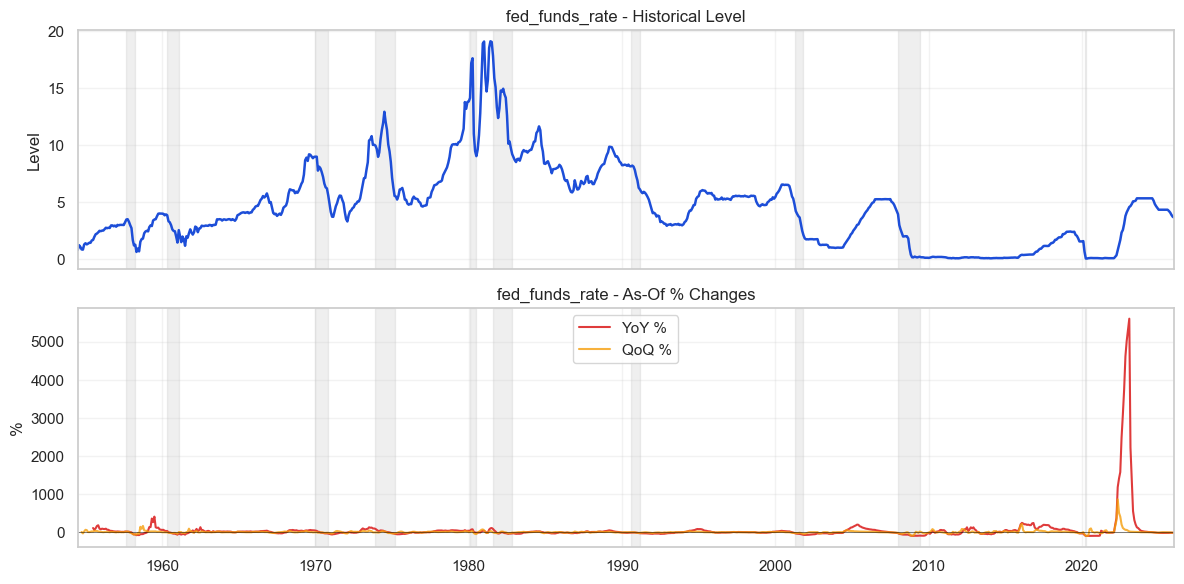

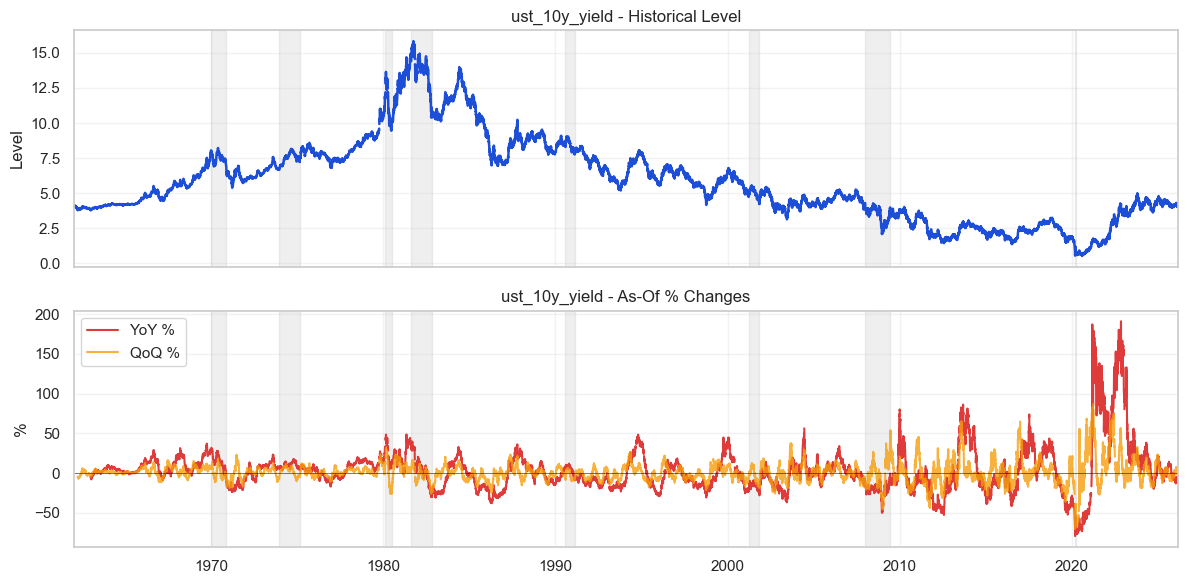

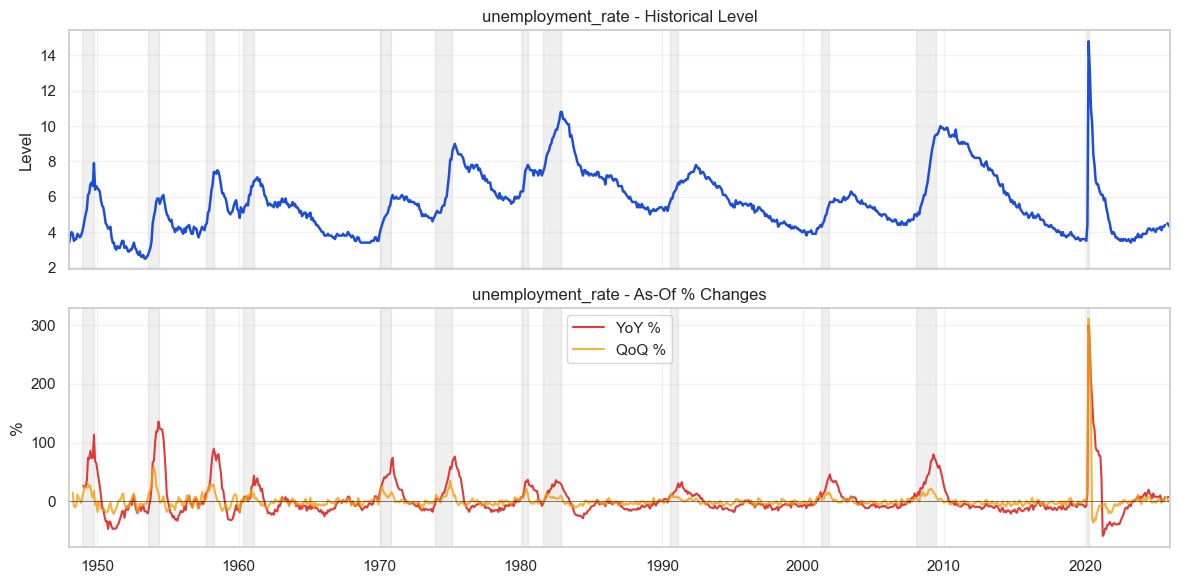

In [9]:
focus_metrics = ["fed_funds_rate", "ust_10y_yield", "unemployment_rate"]

for metric_name in focus_metrics:
    g = macro_final[macro_final["metric"] == metric_name].sort_values("date").copy()
    if g.empty:
        continue

    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax_top.plot(g["date"], g["value"], color="#1d4ed8", linewidth=1.8)
    apply_recession_shading(ax_top, g["date"].min(), g["date"].max())
    ax_top.set_title(f"{metric_name} - Historical Level")
    ax_top.set_ylabel("Level")
    ax_top.grid(True, alpha=0.25)

    ax_bottom.plot(g["date"], g["pct_1y"], label="YoY %", color="#dc2626", alpha=0.9)
    ax_bottom.plot(g["date"], g["pct_1q"], label="QoQ %", color="#f59e0b", alpha=0.8)
    ax_bottom.axhline(0, color="black", linewidth=0.7, alpha=0.5)
    apply_recession_shading(ax_bottom, g["date"].min(), g["date"].max())
    ax_bottom.set_title(f"{metric_name} - As-Of % Changes")
    ax_bottom.set_ylabel("%")
    ax_bottom.legend()
    ax_bottom.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

## Regimes, lead-lag, persistence, and curve signals

Builds monthly and weekly end-of-period panels once, then runs:
- Rate regime comparisons (hikes/holds/cuts)
- VIX lead-lag vs yields (with subperiod stability)
- Policy lead-lag vs unemployment and rolling lag correlations
- Inflation persistence using CPI YoY rolling statistics
- Yield curve inversion diagnostics and overlays

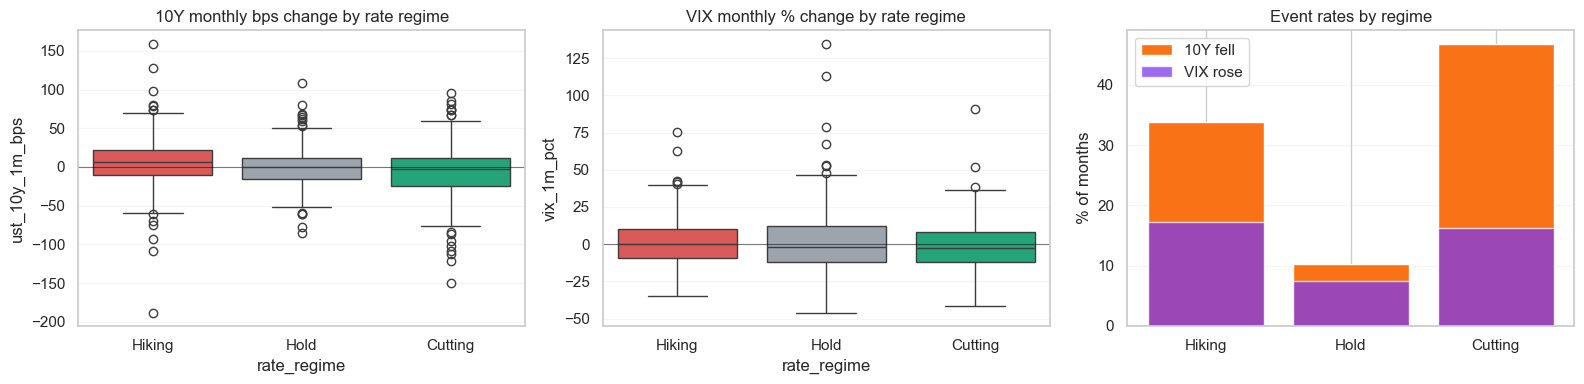

Event rate summary (percent of months):
- Hiking: 10Y fell=33.9%, VIX rose=17.3%
- Hold: 10Y fell=10.3%, VIX rose=7.5%
- Cutting: 10Y fell=46.7%, VIX rose=16.3%


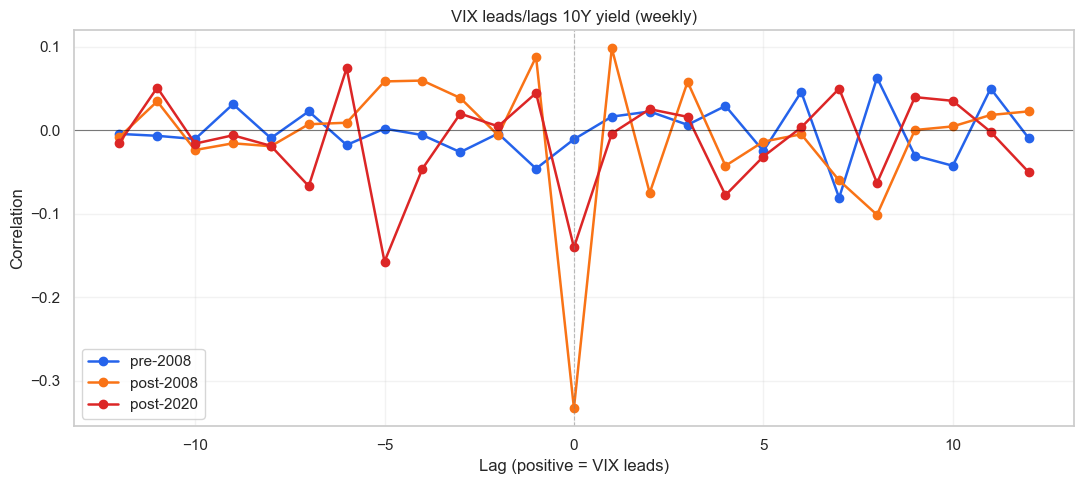

Best lag per subperiod (weekly VIX% vs 10Y bps):
- pre-2008: best_lag=7, corr=-0.08
- post-2008: best_lag=0, corr=-0.33
- post-2020: best_lag=-5, corr=-0.16


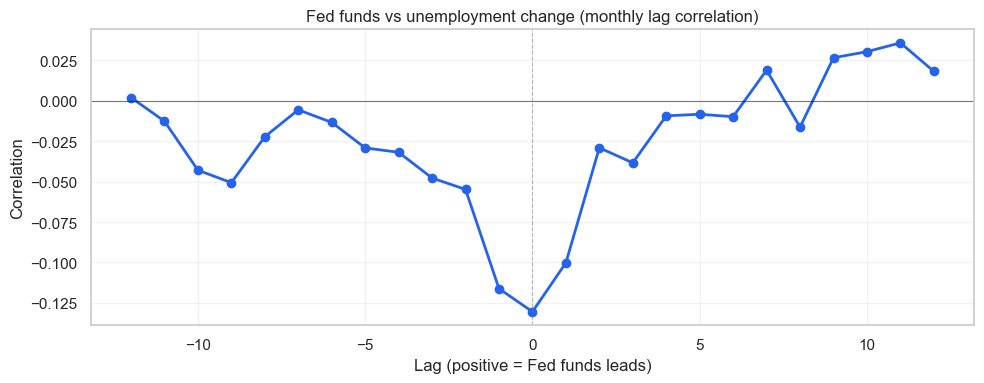

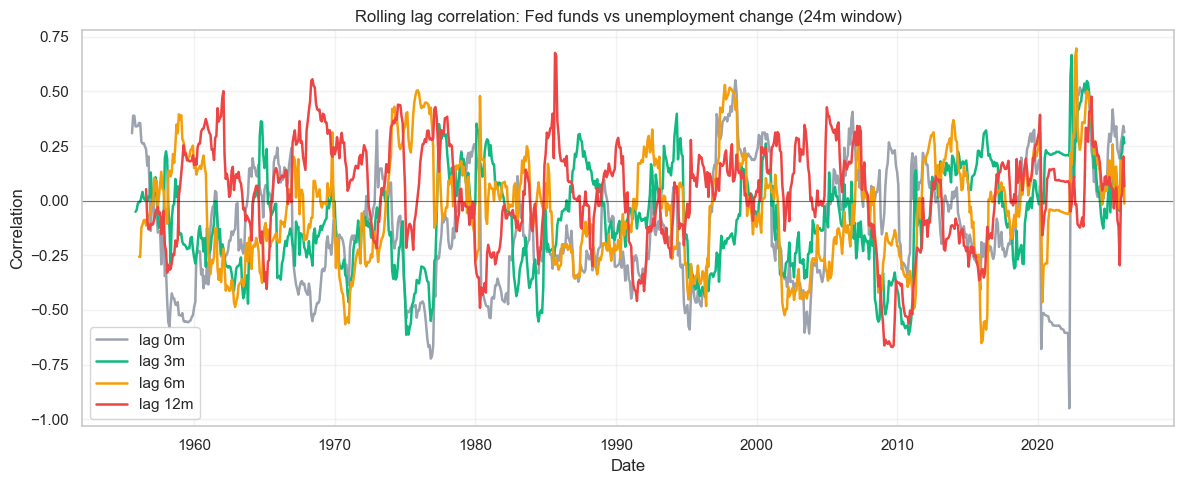

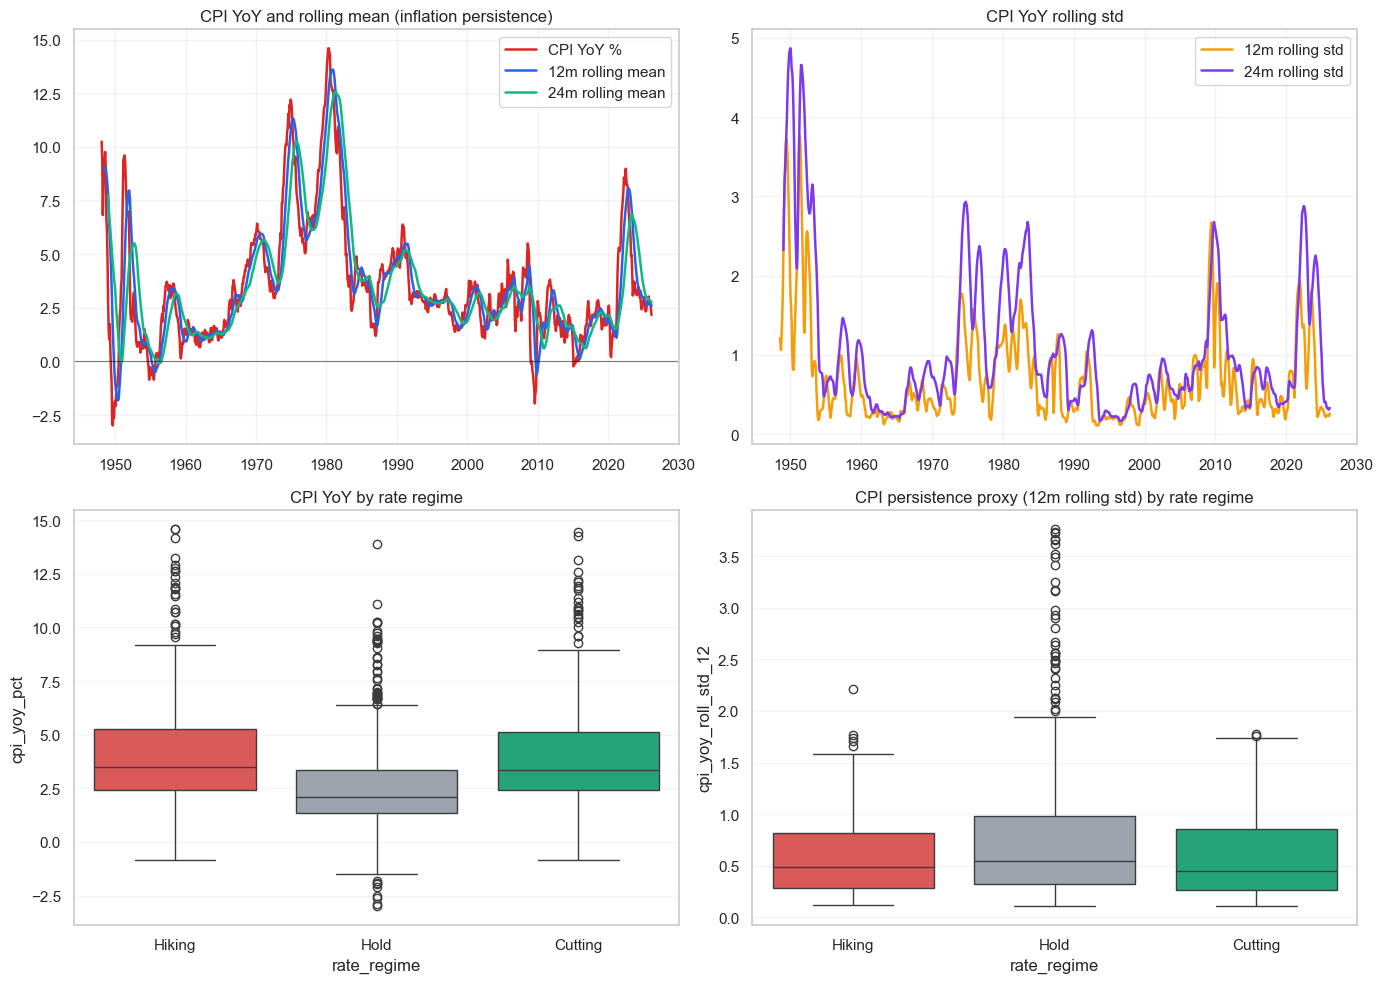

Signal hit rates (inversion-based):
- P(unemployment higher in 6m | inversion) = 62.8%
- P(unemployment higher in 12m | inversion) = 87.2%
- P(recession in next 12m | inversion) = 44.7%


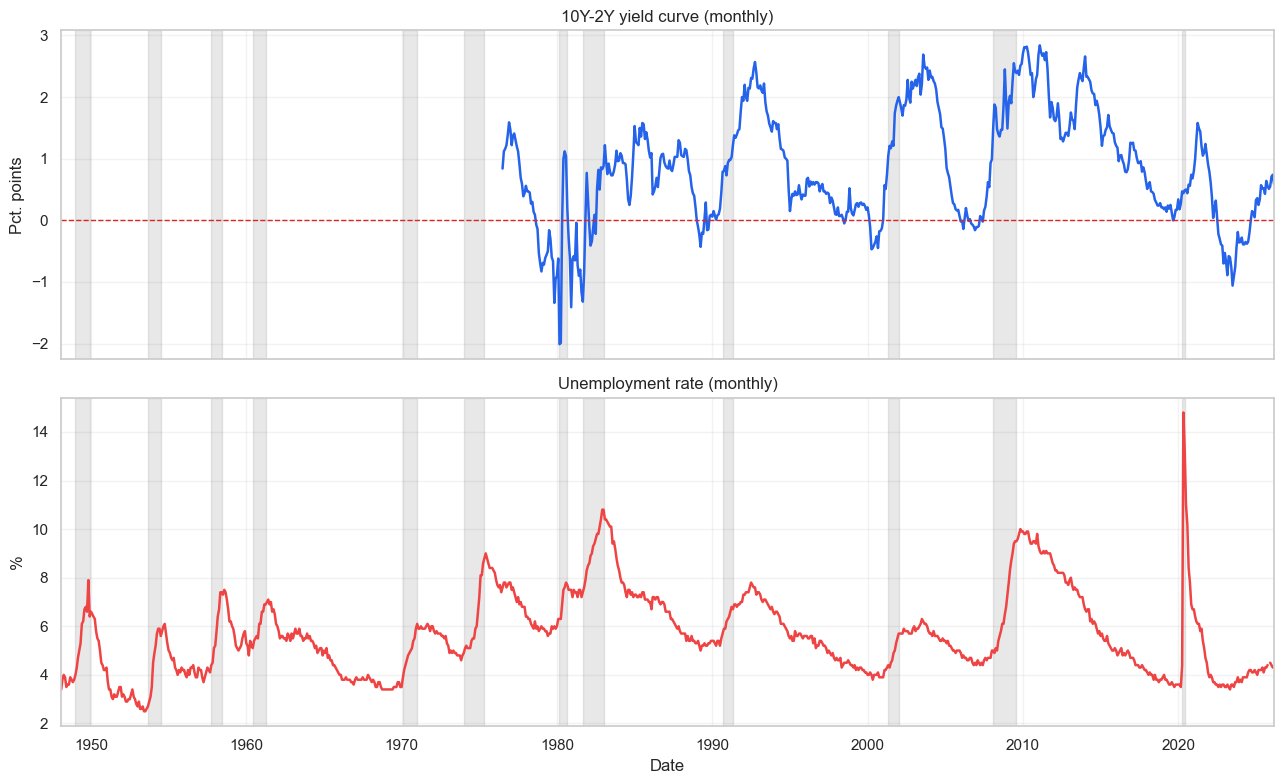

In [58]:
# Monthly end-of-period panel
monthly_panel = (
    macro_final.assign(month_end=lambda d: d["date"].dt.to_period("M").dt.to_timestamp("M"))
    .sort_values(["metric", "date"])
    .groupby(["metric", "month_end"], as_index=False)
    .last()
    .pivot(index="month_end", columns="metric", values="value")
    .sort_index()
)

# Weekly end-of-period panel
weekly_panel = (
    macro_final.assign(week_end=lambda d: d["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize())
    .sort_values(["metric", "date"])
    .groupby(["metric", "week_end"], as_index=False)
    .last()
    .pivot(index="week_end", columns="metric", values="value")
    .sort_index()
)

# Monthly features used for regimes and forward-looking comparisons
m = monthly_panel.copy()

if "fed_funds_rate" in m.columns:
    m["fed_funds_1m_bps"] = m["fed_funds_rate"].diff() * 100
    m["rate_regime"] = "Hold"
    m.loc[m["fed_funds_1m_bps"] >= 5, "rate_regime"] = "Hiking"
    m.loc[m["fed_funds_1m_bps"] <= -5, "rate_regime"] = "Cutting"

if "ust_10y_yield" in m.columns:
    m["ust_10y_1m_bps"] = m["ust_10y_yield"].diff() * 100

if "ust_2y_yield" in m.columns:
    m["ust_2y_1m_bps"] = m["ust_2y_yield"].diff() * 100

if "curve_10y_2y" in m.columns:
    m["curve_inverted"] = (m["curve_10y_2y"] < 0).astype(float)

if "vix" in m.columns:
    m["vix_1m_pct"] = m["vix"].pct_change() * 100

if "unemployment_rate" in m.columns:
    m["unemp_1m_chg"] = m["unemployment_rate"].diff()
    m["unemp_6m_fwd_chg"] = m["unemployment_rate"].shift(-6) - m["unemployment_rate"]
    m["unemp_12m_fwd_chg"] = m["unemployment_rate"].shift(-12) - m["unemployment_rate"]

if "cpi" in m.columns:
    m["cpi_yoy_pct"] = m["cpi"].pct_change(12) * 100
    m["cpi_yoy_roll_mean_12"] = m["cpi_yoy_pct"].rolling(12, min_periods=6).mean()
    m["cpi_yoy_roll_std_12"] = m["cpi_yoy_pct"].rolling(12, min_periods=6).std()
    m["cpi_yoy_roll_mean_24"] = m["cpi_yoy_pct"].rolling(24, min_periods=12).mean()
    m["cpi_yoy_roll_std_24"] = m["cpi_yoy_pct"].rolling(24, min_periods=12).std()

# Recession flags
if "recession" in m.columns:
    rec_binary = (m["recession"].fillna(0) >= 0.5).astype(int)
    m["recession_flag"] = rec_binary
    m["recession_next_12m"] = rec_binary.iloc[::-1].rolling(12, min_periods=1).max().iloc[::-1].astype(float)
else:
    m["recession_flag"] = np.nan
    m["recession_next_12m"] = np.nan

# Weekly transforms for VIX vs yields
w = weekly_panel.copy()
if "vix" in w.columns:
    w["vix_pct"] = w["vix"].pct_change() * 100
if "ust_10y_yield" in w.columns:
    w["ust_10y_bps"] = w["ust_10y_yield"].diff() * 100

def lag_corr(series_a, series_b, max_lag=12) -> pd.DataFrame:
    # Positive lag means series_a leads series_b
    df_pair = pd.concat([series_a.rename("a"), series_b.rename("b")], axis=1).dropna()
    rows = []
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            x = df_pair["a"].shift(lag)
            y = df_pair["b"]
        elif lag < 0:
            x = df_pair["a"]
            y = df_pair["b"].shift(-lag)
        else:
            x = df_pair["a"]
            y = df_pair["b"]

        valid = pd.concat([x, y], axis=1).dropna()
        corr_val = valid.iloc[:, 0].corr(valid.iloc[:, 1]) if len(valid) >= 10 else np.nan
        rows.append({"lag": lag, "corr": corr_val, "n": len(valid)})
    return pd.DataFrame(rows)

# Rate regime event rates and visuals
if "rate_regime" in m.columns:
    if "ust_10y_1m_bps" in m.columns:
        m["teny_falls"] = (m["ust_10y_1m_bps"] < 0).astype(float)
    if "vix_1m_pct" in m.columns:
        m["vix_rises"] = (m["vix_1m_pct"] > 0).astype(float)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    palette_regime = {"Hiking": "#ef4444", "Hold": "#9ca3af", "Cutting": "#10b981"}

    if "ust_10y_1m_bps" in m.columns:
        sns.boxplot(
            data=m.dropna(subset=["ust_10y_1m_bps"]),
            x="rate_regime", y="ust_10y_1m_bps",
            order=["Hiking", "Hold", "Cutting"],
            palette=palette_regime, ax=axes[0]
        )
        axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
        axes[0].set_title("10Y monthly bps change by rate regime")
        axes[0].grid(True, axis="y", alpha=0.2)

    if "vix_1m_pct" in m.columns:
        sns.boxplot(
            data=m.dropna(subset=["vix_1m_pct"]),
            x="rate_regime", y="vix_1m_pct",
            order=["Hiking", "Hold", "Cutting"],
            palette=palette_regime, ax=axes[1]
        )
        axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
        axes[1].set_title("VIX monthly % change by rate regime")
        axes[1].grid(True, axis="y", alpha=0.2)

    event_rows = []
    for regime_name in ["Hiking", "Hold", "Cutting"]:
        slice_df = m[m["rate_regime"] == regime_name]
        pct_10y_fell = slice_df["teny_falls"].mean() * 100 if "teny_falls" in slice_df.columns else np.nan
        pct_vix_rose = slice_df["vix_rises"].mean() * 100 if "vix_rises" in slice_df.columns else np.nan
        event_rows.append((regime_name, pct_10y_fell, pct_vix_rose))

    labels = [row[0] for row in event_rows]
    vals_10y = [row[1] for row in event_rows]
    vals_vix = [row[2] for row in event_rows]

    axes[2].bar(labels, vals_10y, label="10Y fell", color="#f97316")
    axes[2].bar(labels, vals_vix, bottom=np.zeros(len(vals_vix)), label="VIX rose", color="#7c3aed", alpha=0.75)
    axes[2].set_title("Event rates by regime")
    axes[2].set_ylabel("% of months")
    axes[2].grid(True, axis="y", alpha=0.2)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print("Event rate summary (percent of months):")
    for regime_name, pct_10y_fell, pct_vix_rose in event_rows:
        print(f"- {regime_name}: 10Y fell={pct_10y_fell:.1f}%, VIX rose={pct_vix_rose:.1f}%")

# VIX lead-lag vs yields and subperiod stability
if "vix_pct" in w.columns and "ust_10y_bps" in w.columns:
    period_masks = {
        "pre-2008": w.index < pd.Timestamp("2008-01-01"),
        "post-2008": (w.index >= pd.Timestamp("2008-01-01")) & (w.index < pd.Timestamp("2020-01-01")),
        "post-2020": w.index >= pd.Timestamp("2020-01-01"),
    }

    profiles = {}
    for period_name, mask in period_masks.items():
        temp = w.loc[mask, ["vix_pct", "ust_10y_bps"]].dropna()
        if len(temp) >= 30:
            profiles[period_name] = lag_corr(temp["vix_pct"], temp["ust_10y_bps"], max_lag=12)

    if profiles:
        plt.figure(figsize=(11, 5))
        color_map_period = {"pre-2008": "#2563eb", "post-2008": "#f97316", "post-2020": "#dc2626"}
        best_lines = []

        for period_name, res in profiles.items():
            plt.plot(res["lag"], res["corr"], marker="o", linewidth=1.8, label=period_name, color=color_map_period.get(period_name))
            if res["corr"].notna().any():
                best_idx = res["corr"].abs().idxmax()
                best_lag = int(res.loc[best_idx, "lag"])
                best_corr = float(res.loc[best_idx, "corr"])
                best_lines.append((period_name, best_lag, best_corr))

        plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        plt.title("VIX leads/lags 10Y yield (weekly)")
        plt.xlabel("Lag (positive = VIX leads)")
        plt.ylabel("Correlation")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

        print("Best lag per subperiod (weekly VIX% vs 10Y bps):")
        for period_name, best_lag, best_corr in best_lines:
            print(f"- {period_name}: best_lag={best_lag}, corr={best_corr:.2f}")

# Unemployment reaction delay to policy with rolling lag correlations
if "fed_funds_1m_bps" in m.columns and "unemp_1m_chg" in m.columns:
    unemp_lag = lag_corr(m["fed_funds_1m_bps"], m["unemp_1m_chg"], max_lag=12)

    plt.figure(figsize=(10, 4))
    plt.plot(unemp_lag["lag"], unemp_lag["corr"], marker="o", linewidth=2, color="#2563eb")
    plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    plt.title("Fed funds vs unemployment change (monthly lag correlation)")
    plt.xlabel("Lag (positive = Fed funds leads)")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    lag_set = [0, 3, 6, 12]
    rolling_corr_df = pd.DataFrame(index=m.index)
    for lag in lag_set:
        x = m["fed_funds_1m_bps"].shift(lag) if lag > 0 else m["fed_funds_1m_bps"]
        y = m["unemp_1m_chg"]
        pair = pd.concat([x.rename("x"), y.rename("y")], axis=1)
        rolling_corr_df[f"lag_{lag}"] = pair["x"].rolling(24, min_periods=12).corr(pair["y"])

    plt.figure(figsize=(12, 5))
    lag_colors = {0: "#9ca3af", 3: "#10b981", 6: "#f59e0b", 12: "#ef4444"}
    for lag in lag_set:
        plt.plot(rolling_corr_df.index, rolling_corr_df[f"lag_{lag}"], label=f"lag {lag}m", color=lag_colors.get(lag), linewidth=1.8)

    plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    plt.title("Rolling lag correlation: Fed funds vs unemployment change (24m window)")
    plt.xlabel("Date")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# Inflation persistence visuals
if "cpi_yoy_pct" in m.columns and "rate_regime" in m.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(m.index, m["cpi_yoy_pct"], label="CPI YoY %", color="#dc2626", linewidth=1.8)
    axes[0, 0].plot(m.index, m["cpi_yoy_roll_mean_12"], label="12m rolling mean", color="#2563eb", linewidth=1.8)
    axes[0, 0].plot(m.index, m["cpi_yoy_roll_mean_24"], label="24m rolling mean", color="#10b981", linewidth=1.8)
    axes[0, 0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
    axes[0, 0].set_title("CPI YoY and rolling mean (inflation persistence)")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.25)

    axes[0, 1].plot(m.index, m["cpi_yoy_roll_std_12"], label="12m rolling std", color="#f59e0b", linewidth=1.8)
    axes[0, 1].plot(m.index, m["cpi_yoy_roll_std_24"], label="24m rolling std", color="#7c3aed", linewidth=1.8)
    axes[0, 1].set_title("CPI YoY rolling std")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.25)

    sns.boxplot(
        data=m.dropna(subset=["cpi_yoy_pct", "rate_regime"]),
        x="rate_regime", y="cpi_yoy_pct",
        order=["Hiking", "Hold", "Cutting"],
        palette={"Hiking": "#ef4444", "Hold": "#9ca3af", "Cutting": "#10b981"},
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("CPI YoY by rate regime")
    axes[1, 0].grid(True, axis="y", alpha=0.2)

    sns.boxplot(
        data=m.dropna(subset=["cpi_yoy_roll_std_12", "rate_regime"]),
        x="rate_regime", y="cpi_yoy_roll_std_12",
        order=["Hiking", "Hold", "Cutting"],
        palette={"Hiking": "#ef4444", "Hold": "#9ca3af", "Cutting": "#10b981"},
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("CPI persistence proxy (12m rolling std) by rate regime")
    axes[1, 1].grid(True, axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

# Yield curve comparisons and overlays
need_cols = {"curve_10y_2y", "fed_funds_rate", "unemployment_rate"}
if need_cols.issubset(m.columns):
    m["signal_inversion"] = (m["curve_10y_2y"] < 0).astype(float)

    if "fed_funds_1m_bps" in m.columns:
        m["signal_hiking"] = (m["fed_funds_1m_bps"] >= 5).astype(float)
        m["signal_cutting"] = (m["fed_funds_1m_bps"] <= -5).astype(float)

    if "unemp_6m_fwd_chg" in m.columns:
        m["unemp_up_6m"] = (m["unemp_6m_fwd_chg"] > 0).astype(float)
    if "unemp_12m_fwd_chg" in m.columns:
        m["unemp_up_12m"] = (m["unemp_12m_fwd_chg"] > 0).astype(float)

    def cond_prob(flag_col: str, outcome_col: str) -> float:
        # Computes P(outcome | flag) in percent
        valid = m[[flag_col, outcome_col]].dropna()
        if valid.empty or (valid[flag_col] == 1).sum() == 0:
            return np.nan
        return valid.loc[valid[flag_col] == 1, outcome_col].mean() * 100

    p_unemp6_inv = cond_prob("signal_inversion", "unemp_up_6m") if "unemp_up_6m" in m.columns else np.nan
    p_unemp12_inv = cond_prob("signal_inversion", "unemp_up_12m") if "unemp_up_12m" in m.columns else np.nan
    p_rec12_inv = cond_prob("signal_inversion", "recession_next_12m") if "recession_next_12m" in m.columns else np.nan

    print("Signal hit rates (inversion-based):")
    if pd.notna(p_unemp6_inv):
        print(f"- P(unemployment higher in 6m | inversion) = {p_unemp6_inv:.1f}%")
    if pd.notna(p_unemp12_inv):
        print(f"- P(unemployment higher in 12m | inversion) = {p_unemp12_inv:.1f}%")
    if pd.notna(p_rec12_inv):
        print(f"- P(recession in next 12m | inversion) = {p_rec12_inv:.1f}%")

    # Build recession spans from monthly recession flag
    recession_spans = []
    if "recession_flag" in m.columns and m["recession_flag"].notna().any():
        rec_series = m["recession_flag"].fillna(0).astype(int)
        in_recession = False
        start_date = None

        for dt, flag in rec_series.items():
            if flag == 1 and not in_recession:
                start_date = dt
                in_recession = True
            elif flag == 0 and in_recession:
                recession_spans.append((start_date, dt))
                in_recession = False

        if in_recession:
            recession_spans.append((start_date, rec_series.index.max()))

    # Plot two line charts with recession shading
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    # 10Y-2Y curve
    axes[0].plot(m.index, m["curve_10y_2y"], color="#2563eb", linewidth=1.8)
    axes[0].axhline(0, color="#dc2626", linestyle="--", linewidth=1)
    for start_date, end_date in recession_spans:
        axes[0].axvspan(start_date, end_date, color="gray", alpha=0.18)
    axes[0].set_title("10Y-2Y yield curve (monthly)")
    axes[0].set_ylabel("Pct. points")
    axes[0].grid(True, alpha=0.25)

    # Unemployment rate
    axes[1].plot(m.index, m["unemployment_rate"], color="#ef4444", linewidth=1.8)
    for start_date, end_date in recession_spans:
        axes[1].axvspan(start_date, end_date, color="gray", alpha=0.18)
    axes[1].set_title("Unemployment rate (monthly)")
    axes[1].set_ylabel("%")
    axes[1].set_xlabel("Date")
    axes[1].grid(True, alpha=0.25)

    # Start x-axis at the first actual plotted observation
    curve_start = m["curve_10y_2y"].dropna().index.min()
    unemp_start = m["unemployment_rate"].dropna().index.min()
    x_start = min(curve_start, unemp_start)
    x_end = max(
        m["curve_10y_2y"].dropna().index.max(),
        m["unemployment_rate"].dropna().index.max()
    )

    axes[0].set_xlim(x_start, x_end)
    axes[1].set_xlim(x_start, x_end)
    
    plt.tight_layout()
    plt.show()

## Macro analysis table (bps transforms and rolling stats)

Creates a diagnostic long table with rate changes in basis points and rolling measures used for stress and stability checks.

In [19]:
macro_analysis = macro_final.copy().sort_values(["metric", "date"]).reset_index(drop=True)

# Basis point conversions for rate metrics
rate_metrics = {"fed_funds_rate", "ust_10y_yield", "ust_2y_yield"}
for metric_name in rate_metrics:
    mask = macro_analysis["metric"] == metric_name
    macro_analysis.loc[mask, "chg_prev_obs_bps"] = macro_analysis.loc[mask, "chg_prev_obs"] * 100
    macro_analysis.loc[mask, "chg_1m_bps"] = macro_analysis.loc[mask, "chg_1m"] * 100
    macro_analysis.loc[mask, "chg_1q_bps"] = macro_analysis.loc[mask, "chg_1q"] * 100
    macro_analysis.loc[mask, "chg_1y_bps"] = macro_analysis.loc[mask, "chg_1y"] * 100

# Rolling diagnostics per metric
macro_analysis["rolling_z_126"] = np.nan
macro_analysis["rolling_pct_252"] = np.nan
macro_analysis["rolling_vol_21"] = np.nan
macro_analysis["rolling_vol_63"] = np.nan

for metric_name, g in macro_analysis.groupby("metric", sort=False):
    g = g.sort_values("date").copy()
    idx = g.index

    roll_mean = g["value"].rolling(126, min_periods=30).mean()
    roll_std = g["value"].rolling(126, min_periods=30).std()
    macro_analysis.loc[idx, "rolling_z_126"] = (g["value"] - roll_mean) / roll_std.replace(0, np.nan)

    values = g["value"].to_numpy()
    rolling_pct_list = []
    for i in range(len(g)):
        start = max(0, i - 251)
        window = pd.Series(values[start:i+1]).dropna()
        current = values[i]
        if len(window) < 20 or pd.isna(current):
            rolling_pct_list.append(np.nan)
        else:
            rolling_pct_list.append(window.rank(pct=True).iloc[-1] * 100)
    macro_analysis.loc[idx, "rolling_pct_252"] = rolling_pct_list

    pct_prev = g["pct_chg_prev_obs"]
    macro_analysis.loc[idx, "rolling_vol_21"] = pct_prev.rolling(21, min_periods=10).std()
    macro_analysis.loc[idx, "rolling_vol_63"] = pct_prev.rolling(63, min_periods=20).std()

macro_analysis.tail(15)

,metric,date,category,unit,value,year,quarter_num,quarter,month,month_start,quarter_start,week_start,median_gap_days,frequency_hint,value_prev_obs,chg_prev_obs,pct_chg_prev_obs,chg_1obs,chg_5obs,chg_21obs,pct_252obs,value_base100,value_1d_ago,ref_date_1d,chg_1d,pct_1d,value_1w_ago,ref_date_1w,chg_1w,pct_1w,value_1m_ago,ref_date_1m,chg_1m,pct_1m,value_1q_ago,ref_date_1q,chg_1q,pct_1q,value_1y_ago,ref_date_1y,chg_1y,pct_1y,z_score,percentile,chg_prev_obs_bps,chg_1m_bps,chg_1q_bps,chg_1y_bps,rolling_z_126,rolling_pct_252,rolling_vol_21,rolling_vol_63
57229,vix,2026-02-09,Risk,Index,17.36,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-09,1.0,daily-ish,17.76,-0.40,-2.252252,-0.40,1.02,2.87,10.855683,100.696056,17.76,2026-02-06,-0.40,-2.252252,16.34,2026-02-02,1.02,6.242350,14.49,2026-01-09,2.87,19.806763,19.08,2025-11-07,-1.72,-9.014675,16.54,2025-02-07,0.82,4.957678,-0.268047,48.751779,NaN,NaN,NaN,NaN,0.173071,51.807229,8.914847,7.565846
57230,vix,2026-02-10,Risk,Index,17.79,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-09,1.0,daily-ish,17.36,0.43,2.476959,0.43,-0.21,2.67,-2.306425,103.190255,17.36,2026-02-09,0.43,2.476959,18.00,2026-02-03,-0.21,-1.166667,14.49,2026-01-09,3.30,22.774327,17.60,2025-11-10,0.19,1.079545,15.81,2025-02-10,1.98,12.523719,-0.212665,51.231797,NaN,NaN,NaN,NaN,0.345000,57.630522,8.891641,7.344602
57231,vix,2026-02-11,Risk,Index,17.65,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-09,1.0,daily-ish,17.79,-0.14,-0.786959,-0.14,-0.99,1.67,-7.007376,102.378190,17.79,2026-02-10,-0.14,-0.786959,18.64,2026-02-04,-0.99,-5.311159,14.49,2026-01-09,3.16,21.808144,17.28,2025-11-11,0.37,2.141204,16.02,2025-02-11,1.63,10.174782,-0.230696,50.437972,NaN,NaN,NaN,NaN,0.279304,56.626506,8.838855,7.344466
57232,vix,2026-02-12,Risk,Index,20.82,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-09,1.0,daily-ish,17.65,3.17,17.960340,3.17,-0.95,4.07,7.153886,120.765661,17.65,2026-02-11,3.17,17.960340,21.77,2026-02-05,-0.95,-4.363803,15.12,2026-01-12,5.70,37.698413,17.51,2025-11-12,3.31,18.903484,15.89,2025-02-12,4.93,31.025802,0.177587,66.840031,NaN,NaN,NaN,NaN,1.583423,78.112450,9.568899,7.525015
57233,vix,2026-02-13,Risk,Index,20.60,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-09,1.0,daily-ish,20.82,-0.22,-1.056676,-0.22,2.84,4.76,7.853403,119.489559,20.82,2026-02-12,-0.22,-1.056676,17.76,2026-02-06,2.84,15.990991,15.98,2026-01-13,4.62,28.911139,20.00,2025-11-13,0.60,3.000000,15.10,2025-02-13,5.50,36.423841,0.149252,65.624658,NaN,NaN,NaN,NaN,1.465199,75.903614,9.457912,7.405748
57234,vix,2026-02-16,Risk,Index,21.20,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-16,1.0,daily-ish,20.60,0.60,2.912621,0.60,3.84,5.34,0.331283,122.969838,20.60,2026-02-13,0.60,2.912621,17.36,2026-02-09,3.84,22.119816,15.86,2026-01-16,5.34,33.669609,19.83,2025-11-14,1.37,6.908724,14.77,2025-02-14,6.43,43.534191,0.226530,68.542648,NaN,NaN,NaN,NaN,1.680184,79.116466,9.454496,7.394407
57235,vix,2026-02-17,Risk,Index,20.29,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-16,1.0,daily-ish,21.20,-0.91,-4.292453,-0.91,2.50,1.45,3.362201,117.691415,21.20,2026-02-16,-0.91,-4.292453,17.79,2026-02-10,2.50,14.052839,15.86,2026-01-16,4.43,27.931904,22.38,2025-11-17,-2.09,-9.338695,15.37,2025-02-17,4.92,32.010410,0.109326,64.157451,NaN,NaN,NaN,NaN,1.283547,73.895582,8.693887,7.255277
57236,vix,2026-02-18,Risk,Index,19.62,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-16,1.0,daily-ish,20.29,-0.67,-3.302119,-0.67,1.97,-0.47,-13.871817,113.805104,20.29,2026-02-17,-0.67,-3.302119,17.65,2026-02-11,1.97,11.161473,15.86,2026-01-16,3.76,23.707440,24.69,2025-11-18,-5.07,-20.534629,15.35,2025-02-18,4.27,27.817590,0.023032,60.910982,NaN,NaN,NaN,NaN,0.992528,70.682731,8.625934,7.116338
57237,vix,2026-02-19,Risk,Index,20.23,2026,1,2026Q1,2026-02,2026-02-01,2026-01-01,2026-02-16,1.0,daily-ish,19.62,0.61,3.109072,0.61,-0.59,3.33,-13.951510,117.343387,19.62,2026-02-18,0.61,3.109072,20.82,2026-02-12,-0.59,-2.833814,18.84,2026-01-19,1.39,7.377919,23

## Rolling volatility and rolling correlation visuals

Uses the rolling measures from the analysis table and compares rolling relationships across key pairs.

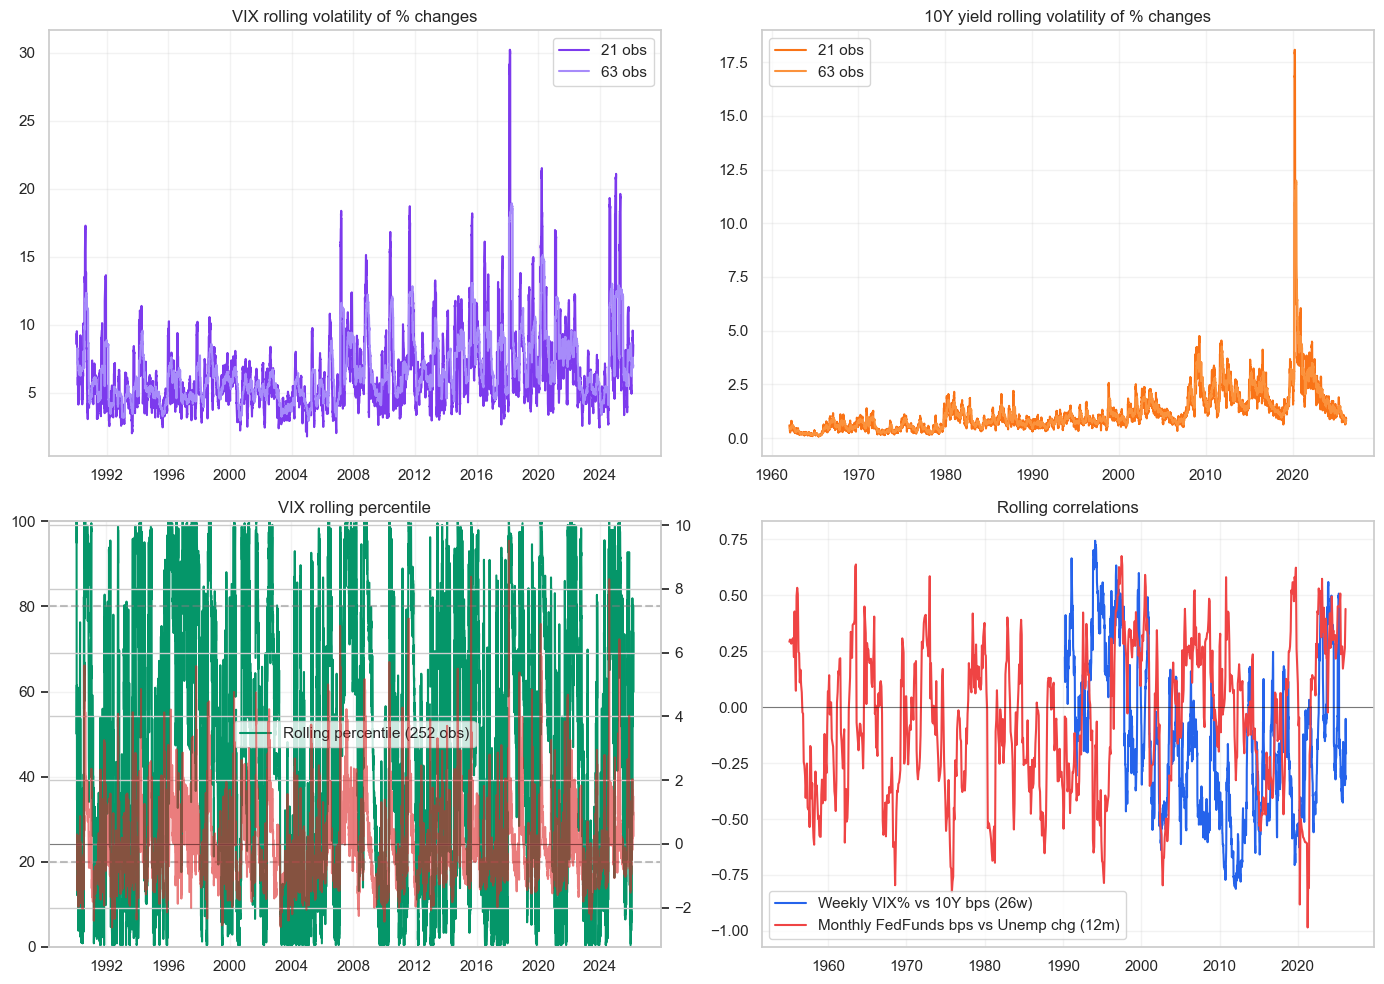

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# VIX rolling volatility
if "vix" in macro_analysis["metric"].unique():
    vix_df = macro_analysis[macro_analysis["metric"] == "vix"].sort_values("date")
    axes[0].plot(vix_df["date"], vix_df["rolling_vol_21"], label="21 obs", color="#7c3aed")
    axes[0].plot(vix_df["date"], vix_df["rolling_vol_63"], label="63 obs", color="#a78bfa")
    axes[0].set_title("VIX rolling volatility of % changes")
    axes[0].legend()
    axes[0].grid(True, alpha=0.25)
else:
    axes[0].set_axis_off()

# 10Y rolling volatility
if "ust_10y_yield" in macro_analysis["metric"].unique():
    y10_df = macro_analysis[macro_analysis["metric"] == "ust_10y_yield"].sort_values("date")
    axes[1].plot(y10_df["date"], y10_df["rolling_vol_21"], label="21 obs", color="#f97316")
    axes[1].plot(y10_df["date"], y10_df["rolling_vol_63"], label="63 obs", color="#fb923c")
    axes[1].set_title("10Y yield rolling volatility of % changes")
    axes[1].legend()
    axes[1].grid(True, alpha=0.25)
else:
    axes[1].set_axis_off()

# VIX rolling percentile and z-score
if "vix" in macro_analysis["metric"].unique():
    vix_df = macro_analysis[macro_analysis["metric"] == "vix"].sort_values("date")
    axes[2].plot(vix_df["date"], vix_df["rolling_pct_252"], color="#059669", label="Rolling percentile (252 obs)")
    axes[2].axhline(80, color="gray", linestyle="--", alpha=0.5)
    axes[2].axhline(20, color="gray", linestyle="--", alpha=0.5)
    axes[2].set_title("VIX rolling percentile")
    axes[2].set_ylim(0, 100)
    axes[2].legend()
    axes[2].grid(True, alpha=0.25)

    ax2b = axes[2].twinx()
    ax2b.plot(vix_df["date"], vix_df["rolling_z_126"], color="#dc2626", alpha=0.6)
    ax2b.axhline(0, color="black", linewidth=0.7, alpha=0.4)
else:
    axes[2].set_axis_off()

# Rolling correlations panel
axes[3].set_title("Rolling correlations")
axes[3].grid(True, alpha=0.25)

if "vix" in weekly_panel.columns and "ust_10y_yield" in weekly_panel.columns:
    wc = weekly_panel.copy()
    wc["vix_pct"] = wc["vix"].pct_change() * 100
    wc["ust_10y_bps"] = wc["ust_10y_yield"].diff() * 100
    pair = wc[["vix_pct", "ust_10y_bps"]].dropna()
    roll_corr = pair["vix_pct"].rolling(26, min_periods=12).corr(pair["ust_10y_bps"])
    axes[3].plot(roll_corr.index, roll_corr, label="Weekly VIX% vs 10Y bps (26w)", color="#2563eb")

if "fed_funds_1m_bps" in m.columns and "unemp_1m_chg" in m.columns:
    pair = m[["fed_funds_1m_bps", "unemp_1m_chg"]].dropna()
    roll_corr = pair["fed_funds_1m_bps"].rolling(12, min_periods=6).corr(pair["unemp_1m_chg"])
    axes[3].plot(roll_corr.index, roll_corr, label="Monthly FedFunds bps vs Unemp chg (12m)", color="#ef4444")

axes[3].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[3].legend()

plt.tight_layout()
plt.show()

## Macro signal score visuals and summary text

Builds a compact scoring approach from percentile extremes, z-scores, trend magnitude, and directional stress, then visualizes the scores.

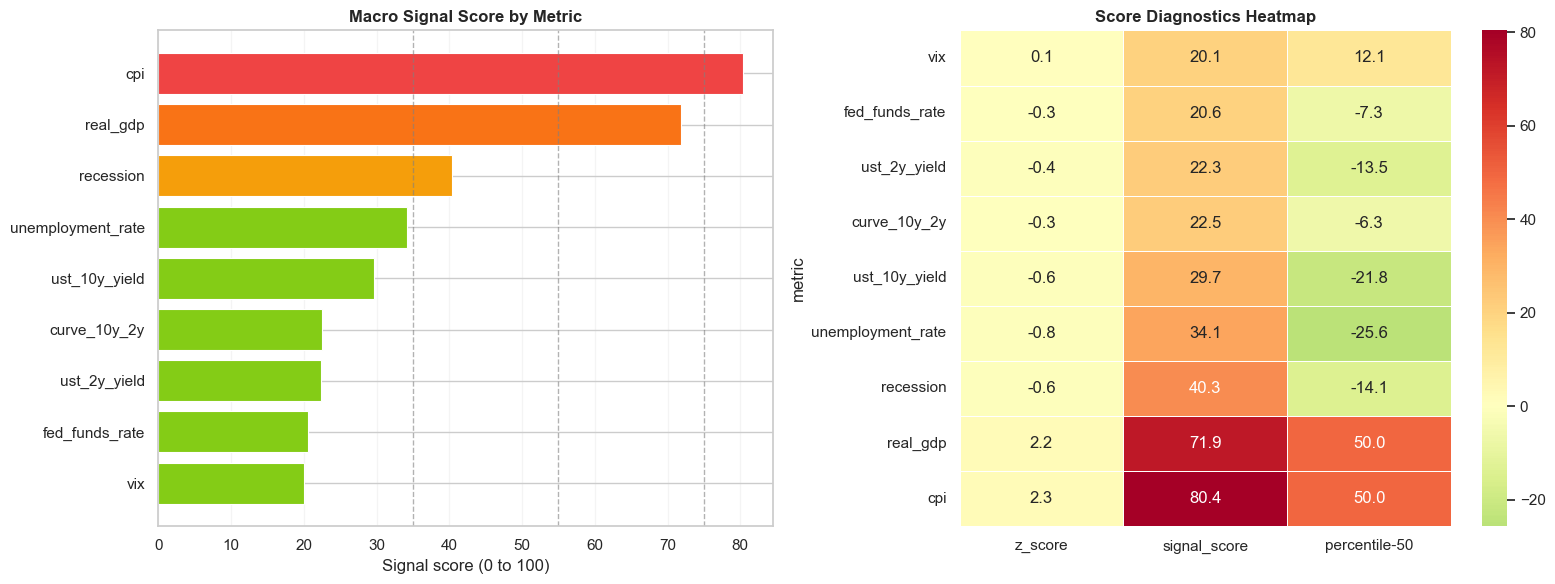

Top risk metrics right now:
- cpi: score=80.4, tag=Extreme, trend=Uptrend, z=2.27, pctile=100.0
- real_gdp: score=71.9, tag=High, trend=Uptrend, z=2.17, pctile=100.0
- recession: score=40.3, tag=Elevated, trend=Downtrend, z=-0.63, pctile=35.9

Lowest risk metrics right now:
- vix: score=20.1, tag=Watch, trend=Rising, z=0.05, pctile=62.1
- fed_funds_rate: score=20.6, tag=Watch, trend=Downtrend, z=-0.27, pctile=42.7
- ust_2y_yield: score=22.3, tag=Watch, trend=Downtrend, z=-0.42, pctile=36.5

Global context:
- Latest month: 2026-02-28
- Rate regime: Hold
- Recession flag: 0
- 10Y-2Y curve: 0.59


In [23]:
# Latest snapshot per metric used for scoring
score_base = macro_latest_snapshot.copy()

# Pull rolling measures from the analysis table
rolling_latest = (
    macro_analysis.sort_values(["metric", "date"])
    .groupby("metric", as_index=False)
    .last()[["metric", "rolling_z_126", "rolling_pct_252", "rolling_vol_21", "rolling_vol_63"]]
)
score_base = score_base.merge(rolling_latest, on="metric", how="left")

# Rate context from latest month
latest_month = m.index.max() if isinstance(m, pd.DataFrame) and len(m) else pd.NaT
rate_regime = m.loc[latest_month, "rate_regime"] if pd.notna(latest_month) and "rate_regime" in m.columns else "N/A"
recession_flag = m.loc[latest_month, "recession_flag"] if pd.notna(latest_month) and "recession_flag" in m.columns else np.nan
curve_latest = m.loc[latest_month, "curve_10y_2y"] if pd.notna(latest_month) and "curve_10y_2y" in m.columns else np.nan

# Preferred trend fields
rate_metrics = {"fed_funds_rate", "ust_10y_yield", "ust_2y_yield"}

score_base["chg_1m_bps"] = np.where(score_base["metric"].isin(rate_metrics), score_base["chg_1m"] * 100, np.nan)
score_base["chg_1q_bps"] = np.where(score_base["metric"].isin(rate_metrics), score_base["chg_1q"] * 100, np.nan)
score_base["chg_1y_bps"] = np.where(score_base["metric"].isin(rate_metrics), score_base["chg_1y"] * 100, np.nan)

score_base["trend_short"] = np.nan
score_base["trend_medium"] = np.nan
score_base["trend_long"] = np.nan

for row_idx, row in score_base.iterrows():
    metric_name = row["metric"]
    if metric_name in rate_metrics:
        score_base.at[row_idx, "trend_short"] = row.get("chg_1m_bps", np.nan)
        score_base.at[row_idx, "trend_medium"] = row.get("chg_1q_bps", np.nan)
        score_base.at[row_idx, "trend_long"] = row.get("chg_1y_bps", np.nan)
    elif metric_name in {"cpi", "real_gdp"}:
        score_base.at[row_idx, "trend_short"] = row.get("pct_1m", np.nan)
        score_base.at[row_idx, "trend_medium"] = row.get("pct_1q", np.nan)
        score_base.at[row_idx, "trend_long"] = row.get("pct_1y", np.nan)
    else:
        score_base.at[row_idx, "trend_short"] = row.get("pct_1m", np.nan)
        score_base.at[row_idx, "trend_medium"] = row.get("pct_1q", np.nan)
        score_base.at[row_idx, "trend_long"] = row.get("pct_1y", np.nan)

def classify_trend(short_val, med_val, long_val):
    ref = med_val if pd.notna(med_val) else short_val
    if pd.isna(ref):
        return "Unknown"
    if ref > 0:
        return "Uptrend" if pd.notna(long_val) and long_val > 0 else "Rising"
    if ref < 0:
        return "Downtrend" if pd.notna(long_val) and long_val < 0 else "Falling"
    return "Flat"

score_base["trend_direction"] = score_base.apply(lambda r: classify_trend(r["trend_short"], r["trend_medium"], r["trend_long"]), axis=1)

# Polarity map: higher value = more stress (positive), lower value = more stress (negative)
polarity_map = {
    "vix": 1,
    "unemployment_rate": 1,
    "cpi": 1,
    "fed_funds_rate": 1,
    "ust_2y_yield": 0,
    "ust_10y_yield": 0,
    "real_gdp": -1,
    "curve_10y_2y": -1,
    "recession": 1
}
score_base["risk_polarity"] = score_base["metric"].map(polarity_map).fillna(0)

# Scoring components
score_base["extreme_pct_score"] = ((score_base["percentile"] - 50).abs() / 50 * 50).clip(0, 50)
score_base["extreme_z_score"] = ((score_base["z_score"].abs() / 3) * 30).clip(0, 30)

trend_mag = score_base["trend_medium"].abs().fillna(0) + 0.5 * score_base["trend_long"].abs().fillna(0)
score_base["trend_mag_score"] = (trend_mag / trend_mag.max(skipna=True) * 20).clip(0, 20) if trend_mag.max(skipna=True) and trend_mag.max(skipna=True) > 0 else 0.0

score_base["directional_risk_score"] = 0.0
pos_mask = score_base["risk_polarity"] > 0
neg_mask = score_base["risk_polarity"] < 0

score_base.loc[pos_mask, "directional_risk_score"] = ((score_base.loc[pos_mask, "z_score"].fillna(0).clip(lower=0) / 3) * 10).clip(0, 10)
score_base.loc[neg_mask, "directional_risk_score"] = (((-score_base.loc[neg_mask, "z_score"].fillna(0)).clip(lower=0) / 3) * 10).clip(0, 10)

score_base["rolling_stress_score"] = 0.0
vix_mask = score_base["metric"] == "vix"
if "rolling_pct_252" in score_base.columns:
    score_base.loc[vix_mask, "rolling_stress_score"] = ((score_base.loc[vix_mask, "rolling_pct_252"].fillna(50) - 50).clip(lower=0) / 50 * 10).clip(0, 10)

score_base["signal_score"] = (
    score_base["extreme_pct_score"].fillna(0) +
    score_base["extreme_z_score"].fillna(0) +
    score_base["trend_mag_score"].fillna(0) +
    score_base["directional_risk_score"].fillna(0) +
    score_base["rolling_stress_score"].fillna(0)
).clip(0, 100)

def risk_tag(x):
    if pd.isna(x):
        return "Unknown"
    if x >= 75:
        return "Extreme"
    if x >= 55:
        return "High"
    if x >= 35:
        return "Elevated"
    if x >= 20:
        return "Watch"
    return "Low"

score_base["risk_tag"] = score_base["signal_score"].apply(risk_tag)

risk_color_map = {
    "Low": "#10b981",
    "Watch": "#84cc16",
    "Elevated": "#f59e0b",
    "High": "#f97316",
    "Extreme": "#ef4444",
    "Unknown": "#9ca3af"
}
score_base["risk_color"] = score_base["risk_tag"].map(risk_color_map)

# Score plot
plot_df = score_base.sort_values("signal_score").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(plot_df["metric"], plot_df["signal_score"], color=plot_df["risk_color"].fillna("#9ca3af"), edgecolor="white", linewidth=0.8)
axes[0].set_title("Macro Signal Score by Metric", fontweight="bold")
axes[0].set_xlabel("Signal score (0 to 100)")
axes[0].axvline(35, linestyle="--", linewidth=1, color="gray", alpha=0.6)
axes[0].axvline(55, linestyle="--", linewidth=1, color="gray", alpha=0.6)
axes[0].axvline(75, linestyle="--", linewidth=1, color="gray", alpha=0.6)
axes[0].grid(True, axis="x", alpha=0.2)

heat_df = plot_df.set_index("metric")[["z_score", "percentile", "signal_score"]].copy()
heat_df["percentile-50"] = heat_df["percentile"] - 50
heat_df = heat_df.drop(columns=["percentile"])
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="RdYlGn_r", center=0, linewidths=0.5, linecolor="white", ax=axes[1])
axes[1].set_title("Score Diagnostics Heatmap", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("metric")

plt.tight_layout()
plt.show()

# Narrative summary
top_risk = score_base.sort_values("signal_score", ascending=False).head(3)
low_risk = score_base.sort_values("signal_score", ascending=True).head(3)

print("Top risk metrics right now:")
for row_idx, row in top_risk.iterrows():
    print(f"- {row['metric']}: score={row['signal_score']:.1f}, tag={row['risk_tag']}, trend={row.get('trend_direction','')}, z={row.get('z_score', np.nan):.2f}, pctile={row.get('percentile', np.nan):.1f}")

print("\nLowest risk metrics right now:")
for row_idx, row in low_risk.iterrows():
    print(f"- {row['metric']}: score={row['signal_score']:.1f}, tag={row['risk_tag']}, trend={row.get('trend_direction','')}, z={row.get('z_score', np.nan):.2f}, pctile={row.get('percentile', np.nan):.1f}")

print("\nGlobal context:")
print(f"- Latest month: {latest_month.date() if pd.notna(latest_month) else 'N/A'}")
print(f"- Rate regime: {rate_regime}")
if pd.notna(recession_flag):
    print(f"- Recession flag: {int(recession_flag)}")
if pd.notna(curve_latest):
    print(f"- 10Y-2Y curve: {curve_latest:.2f}")

## Export file

Writes a single Excel workbook containing the main long table, the latest snapshot, and supporting panels used in the notebook.

In [25]:
export_path = Path("macro_data.xlsx")

def sanitize_sheet_name(name: str) -> str:
    # Excel sheet names must be <= 31 chars and avoid some special chars
    cleaned = "".join(ch if ch.isalnum() or ch in (" ", "-", "_") else "_" for ch in str(name)).strip()
    cleaned = cleaned.replace(" ", "_")
    return (cleaned if cleaned else "sheet")[:31]

def prep_for_excel(df: pd.DataFrame) -> pd.DataFrame:
    # Standardizes column names and removes timezone information from datetimes
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return pd.DataFrame()

    out = df.copy()
    if isinstance(out.index, pd.MultiIndex) or out.index.name is not None:
        out = out.reset_index()

    out.columns = [str(c).strip().lower().replace(" ", "_") for c in out.columns]

    for col in out.columns:
        if pd.api.types.is_period_dtype(out[col]):
            out[col] = out[col].astype(str)
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = pd.to_datetime(out[col]).dt.tz_localize(None)

    return out

# Monthly and weekly wide panels for downstream use
monthly_wide = monthly_panel.reset_index().rename(columns={"month_end": "date"})
weekly_wide = weekly_panel.reset_index().rename(columns={"week_end": "date"})

# A compact quarterly summary (useful for low-frequency review)
macro_quarterly_summary = (
    macro_final.sort_values(["metric", "date"])
    .groupby(["metric", "category", "unit", "year", "quarter"], as_index=False)
    .agg(
        quarter_start=("quarter_start", "min"),
        obs_count=("value", "count"),
        first_value=("value", "first"),
        last_value=("value", "last"),
        avg_value=("value", "mean"),
        min_value=("value", "min"),
        max_value=("value", "max"),
        z_score_last=("z_score", "last"),
    )
    .sort_values(["metric", "quarter_start"])
    .reset_index(drop=True)
)

# Package sheets into one file
sheets = {
    "macro_long_enriched": macro_final,
    "macro_long_raw": final_macro_df,
    "latest_snapshot": macro_latest_snapshot,
    "metric_meta": metric_meta,
    "macro_analysis": macro_analysis,
    "monthly_wide": monthly_wide,
    "weekly_wide": weekly_wide,
    "quarterly_summary": macro_quarterly_summary,
}

with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
    for sheet_name, df in sheets.items():
        df_out = prep_for_excel(df)
        if df_out.empty:
            continue
        df_out.to_excel(writer, sheet_name=sanitize_sheet_name(sheet_name), index=False)

print(f"Saved: {export_path.resolve()}")

Saved: C:\Users\chris\Macro Proj\macro_data.xlsx
